# Market Analysis

## Objective 

This analysis examines the characteristics of the collected Finnish IT job postings, focusing on job category distribution, experience requirements, work models and job titles.

The analysis is based on the collected sample of job postings and is intended to provide an exploratory view of the dataset rather than a representative picture of the entire Finnish IT job market.

# Load Data


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/jobs_cleaned.csv")


In [29]:
df["job_category"] = df["job_id"].str[:3]

## 2. Job Posting by Category

### Question

How are the collected job posting distributed across the four job categories? 

### Method

The number of posting in each category is counted and compared with the total number of collected posting.

In [13]:
category_counts = df["job_category"].value_counts()

In [14]:
category_percentage = (
    round(category_counts/len(df)
    *100,2)
)

In [15]:
category_percentage

job_category
SWD    52.38
DTA    19.05
DTE    14.29
AIE    14.29
Name: count, dtype: float64

In [30]:
category_summary = (
    pd.DataFrame({
        "job_count" : category_counts,
        "job_percentage": category_percentage
    })
    .reset_index()
    .rename(columns={"job_category":"category"})
)

In [17]:
category_summary

,category,job_count,job_percentage
0,SWD,11,52.38
1,DTA,4,19.05
2,DTE,3,14.29
3,AIE,3,14.29


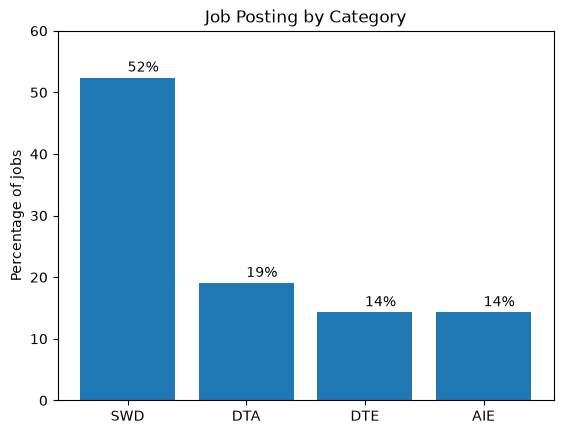

In [31]:
plt.bar(
    category_summary["category"],
    category_summary["job_percentage"]
)
plt.title("Job Posting by Category")
plt.ylabel("Percentage of jobs")
plt.ylim(0,60)

for i, value in enumerate(category_summary["job_percentage"]):
    plt.text(i, value+1, f"{value:.0f}%")

plt.show()

### Key Finding
Software Development (SWD) posting made up the largest share of the collected sample, accounting for 11 of 21 posting (52.38%).

Data Analysis (DTA) represented 4 posting (19.05%), while Data Engineering and AI engineering each represented 3 posting (14.29%).

The uneven distribution should be considered when comparing job categories throughout the analysis.


## 3. Experience Requirements

### Question

How much professional experience is requested in the collected job posting? 

### Method

The minimun experience requirement is used to compare the experience levels requested across the collected posting. Posting withoud a specified experience requirement are excluded from the numerical analysis.

In [26]:
df["years_experience_min"] = (
    df["years_experience_required"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [27]:
df[["years_experience_required","years_experience_min"]]

,years_experience_required,years_experience_min
0,5,5.0
1,2,2.0
2,3,3.0
3,Unknown,NaN
4,3,3.0
5,Unknown,NaN
6,Unknown,NaN
7,Unknown,NaN
8,3,3.0
9,Unknown,NaN


In [33]:
df["years_experience_min"].value_counts().sort_index()

years_experience_min
2.0    2
3.0    5
5.0    3
Name: count, dtype: int64

In [35]:
experience_percentage = (
    df["years_experience_min"]
    .value_counts(normalize=True)
    .sort_index()
    *100
)
experience_percentage

years_experience_min
2.0    20.0
3.0    50.0
5.0    30.0
Name: proportion, dtype: float64

In [38]:
experience_summary = (
    df["years_experience_min"]
    .value_counts()
    .sort_index()
    .rename_axis("years_experience")
    .reset_index(name="job_count")
)

experience_summary["job_percentage"] = (
    experience_summary["job_count"]
    /experience_summary["job_count"].sum()
    *100
)

experience_summary

,years_experience,job_count,job_percentage
0,2.0,2,20.0
1,3.0,5,50.0
2,5.0,3,30.0


#### Note: 
Among the 10 postings with a specific numerical experience requirement, 3 years was the most common minimum requirement, appearing in 50% of these posting

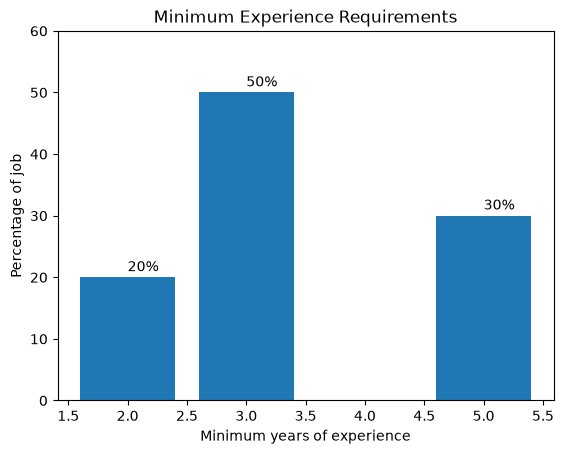

In [45]:
plt.bar(
    experience_summary["years_experience"],
    experience_summary["job_percentage"]
)
plt.title("Minimum Experience Requirements")
plt.ylabel("Percentage of job")
plt.xlabel("Minimum years of experience")
plt.ylim(0,60)

for x, value in zip(
    experience_summary["years_experience"],
    experience_summary["job_percentage"]
):
    plt.text(x, value+1, f"{value:.0f}%")

plt.show()

## Key Finding 

Among the 10 job posting with a specified numerical experience requirement, 3 years was the most common minimum requirement, accounting for 50% of these posting. This was followed by 5 years at 30% and 2 years at 20%.

## 4. Work Model

### Question

What work model are represented in the collected job posting? 

### Method

The work model of each posting is examined to identify the distribution of hybird, remote and on-site arrangements. 

Because some posting may allow more than one work model, the analysis treats each work model as a seprate attribute rather than assumming that the categories are mutually exclusive.


In [48]:
work_model_count = df["work_model"].value_counts()

In [49]:
work_model_percentage = (
    round(work_model_count/len(df)*100,2)
) 

In [50]:
work_model_percentage

work_model
Hybrid           80.95
On-site          14.29
Hybrid;Remote     4.76
Name: count, dtype: float64

In [47]:
df[["is_remote", "is_hybrid", "is_onsite"]].sum()

is_remote     1
is_hybrid    18
is_onsite     3
dtype: int64

In [51]:
work_model_summary = (
    pd.DataFrame({
        "work_model_count" : work_model_count,
        "work_model_percentage": work_model_percentage
    })
    .reset_index()
    
)


In [ ]:
work_model_summary

,work_model,work_model_count,work_model_percentage
0,Hybrid,17,80.95
1,On-site,3,14.29
2,Hybrid;Remote,1,4.76


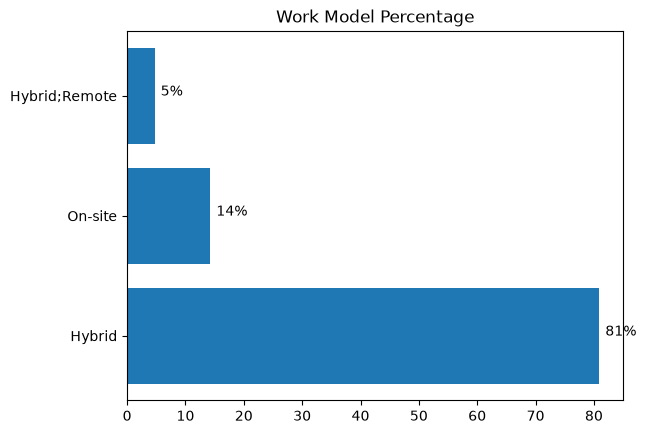

In [57]:
plt.barh(
    work_model_summary["work_model"],
    work_model_summary["work_model_percentage"]
)
for i, value in enumerate(work_model_summary["work_model_percentage"]):
    plt.text(value+1, i, f"{value:.0f}%")
plt.title("Work Model Percentage")

plt.show()

## Key Finding
Hybrid was the dominant work model in the collected sample, accounting for 81% of job postings. On-site posting represented 14%, while one posting 5% allowed both hybrid and remote work.

These figures describe the collected sample of 21 posting and should not be interpreted as representative of the entire Finnish IT job market.

## 5. Limitation

This analysis is based on a small sample of 21 Finnish IT job postings. The results should therefore be interpreted as explorary rather than representative of the entire Finnish IT job market.

The number of postings varies across job categories, with Software Developer representing the largest group in the sample. This uneven distribution affects comparisons between categories. 

Experience analysis is based only on postings with a specific numerical minumum experience requirement. Posting with missing or non-numerical experience information were excluded from this analysis. 

Work model categories are based on how they were recorded in the original job posting. Some posting more than one work model, such as "Hybrid; Remote", so work model counts should not be interpreted as mutually exclusive when using individual work-model flags.